# EDA AIRBNB BERLÍN 02

## 1. IMPORTAR LIBRERÍAS

In [48]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import numpy as np

## 2. CAMBIO DE RUTA EN LOCAL

## 3. ABRIR CSV

In [50]:
df_listings = pd.read_csv('listings_clean.csv')

## 4. ANÁLISIS DE OUTLIERS EN PRICE

In [51]:
print(df_listings['price'].dtype)
print(df_listings['price'].head(10))

float64
0    105.0
1    135.0
2     75.0
3     32.0
4    202.0
5    152.0
6     65.0
7    260.0
8     70.0
9    172.0
Name: price, dtype: float64


In [52]:
print(df_listings['price'].describe())


count     7173.000000
mean       173.150286
std       1221.905038
min          5.000000
25%         73.000000
50%        110.000000
75%        166.000000
max      50000.000000
Name: price, dtype: float64


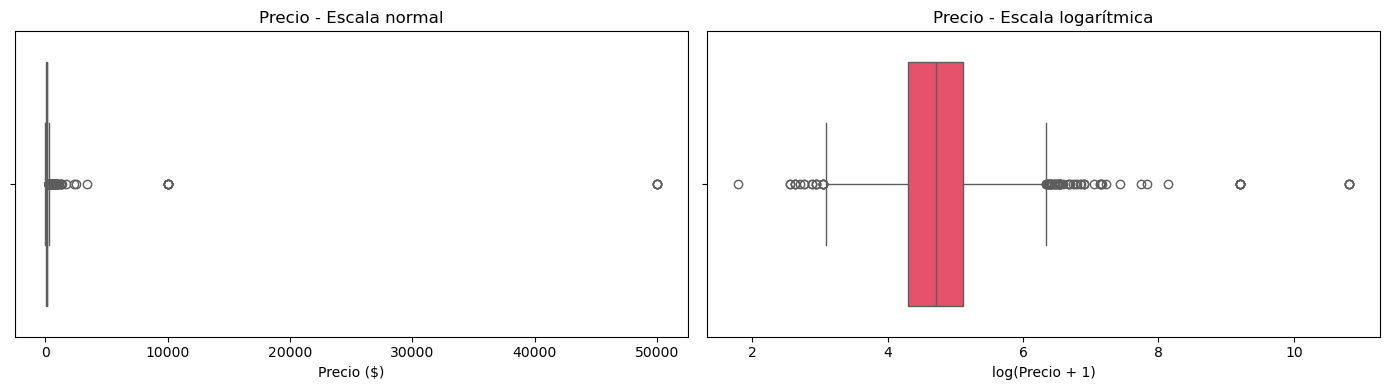

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Izquierda: escala normal
sns.boxplot(x=df_listings['price'], color='#FF385C', ax=axes[0])
axes[0].set_title('Precio - Escala normal')
axes[0].set_xlabel('Precio ($)')

# Derecha: escala logarítmica
sns.boxplot(x=np.log1p(df_listings['price']), color='#FF385C', ax=axes[1])
axes[1].set_title('Precio - Escala logarítmica')
axes[1].set_xlabel('log(Precio + 1)')

plt.tight_layout()
plt.show()

In [54]:
precio_max = df_listings['price'].quantile(0.95)
df_plot = df_listings[df_listings['price'] <= precio_max]

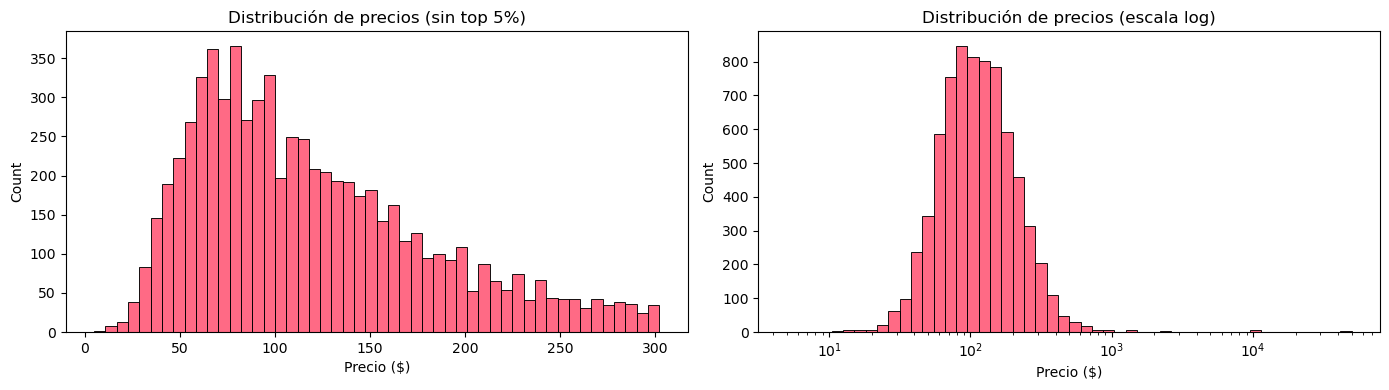

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Opción A: sin top 5%
sns.histplot(df_plot['price'], bins=50, color='#FF385C', ax=axes[0])
axes[0].set_title('Distribución de precios (sin top 5%)')
axes[0].set_xlabel('Precio ($)')

# Opción B: escala logarítmica
sns.histplot(df_listings['price'], bins=50, color='#FF385C', log_scale=True, ax=axes[1])
axes[1].set_title('Distribución de precios (escala log)')
axes[1].set_xlabel('Precio ($)')

plt.tight_layout()
plt.show()

## 5. HEATMAP VARIABLES NUMÉRICAS

In [56]:
numerical = df_listings.select_dtypes(exclude='object')
numerical = numerical.loc[:, ~numerical.columns.isin(['id', 'host_id', 'latitude', 'longitude'])]
corr_matrix = numerical.corr()

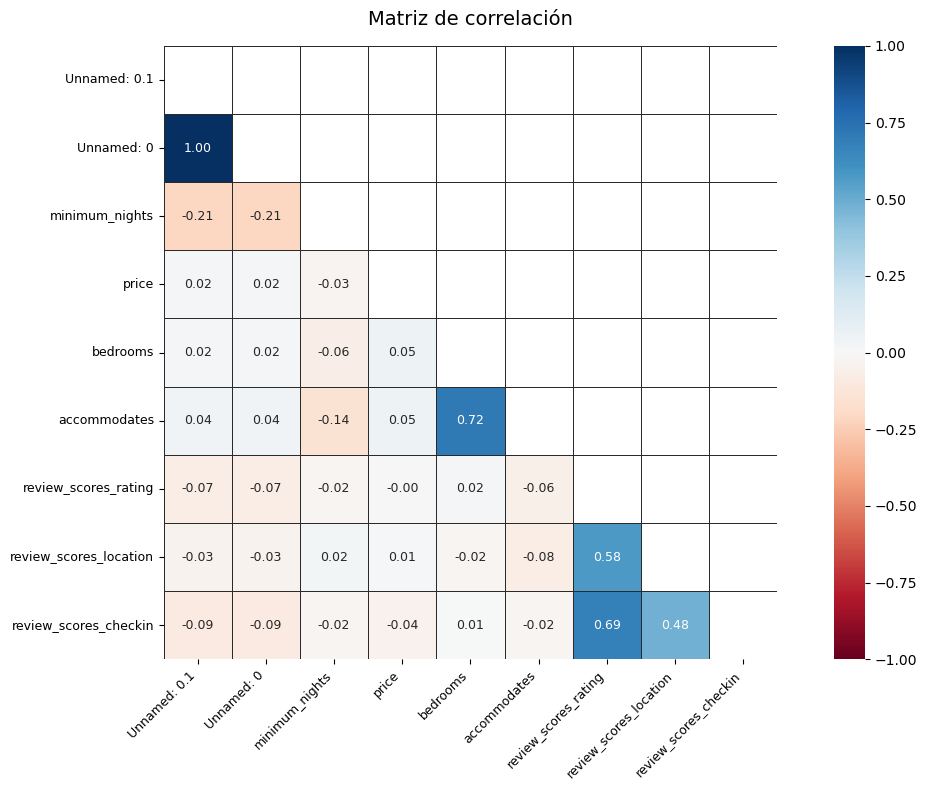

In [57]:
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(12, 8))

sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu', center=0, vmin=-1, vmax=1, annot_kws={"size": 9}, linewidths=0.5, linecolor='#2a2a2a', square=True,
    ax=ax)

ax.set_title('Matriz de correlación', fontsize=14, pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

## 6. BARRIOS CON MÁS ALQUILERES

In [58]:
# Barrios más populares en términos de cantidad de viviendas en alquiler
df_neighbourhood_cleansed = df_listings['neighbourhood_cleansed'].value_counts()
df_neighbourhood_cleansed.to_frame().head(5)

,count
neighbourhood_cleansed,
Alexanderplatz,578
Tempelhofer Vorstadt,345
Frankfurter Allee Süd FK,336
Brunnenstr. Süd,312
Prenzlauer Berg Südwest,249


In [59]:

# Recuento de cada tipo de habitación, ordenado de mayor a menor
df_room_type = df_listings['room_type'].value_counts().sort_values(ascending=False)
df_room_type.to_frame()

,count
room_type,
Entire home/apt,5180
Private room,1824
Hotel room,90
Shared room,79


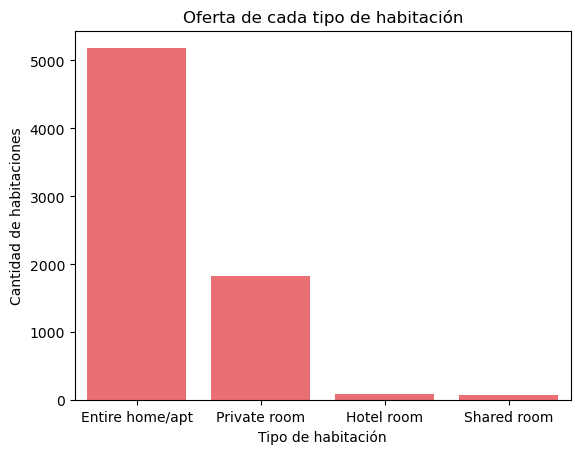

In [60]:
# Gráfico de barras con la oferta de cada tipo de habitación
sns.countplot(x = df_listings['room_type'], order=df_room_type.index, color='#FF5A5F')

# Título y etiquetas de los ejes
plt.title('Oferta de cada tipo de habitación')
plt.xlabel('Tipo de habitación')
plt.ylabel('Cantidad de habitaciones')

plt.show()

In [61]:
# Exportación del dataset
df_listings.to_csv('listings_clean.csv')

## 7. DISTRIBUCIÓN DE VARIABLES NUMÉRICAS

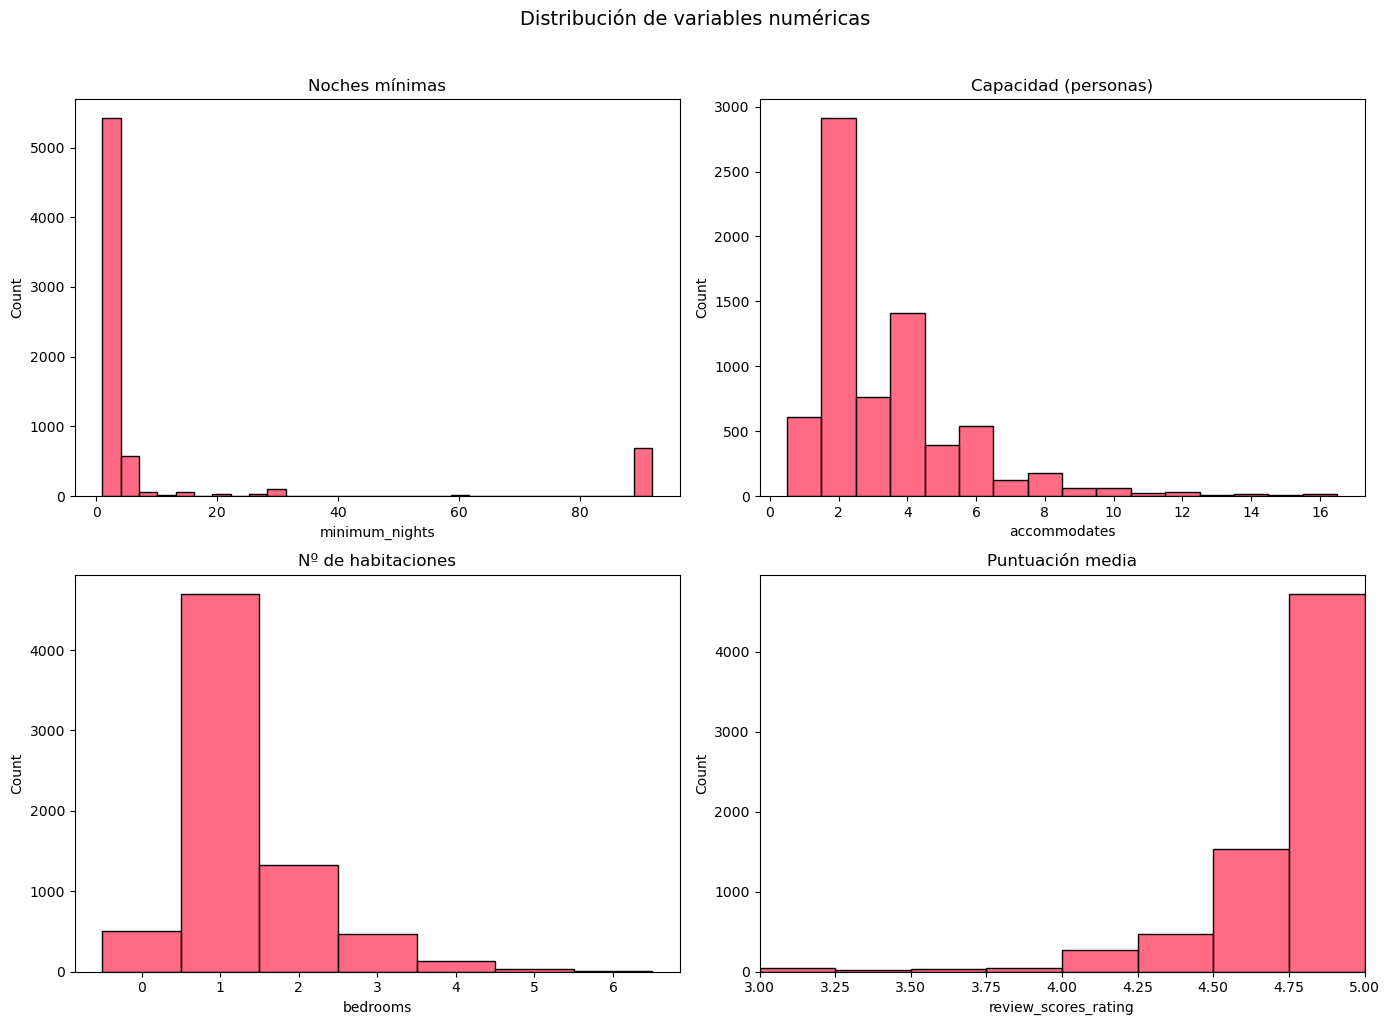

In [64]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Noches mínimas
q95 = df_listings['minimum_nights'].quantile(0.95)
sns.histplot(df_listings[df_listings['minimum_nights'] <= q95]['minimum_nights'], 
             bins=30, color='#FF385C', ax=axes[0][0])
axes[0][0].set_title('Noches mínimas')

# Capacidad
sns.histplot(df_listings['accommodates'], bins=8, color='#FF385C', 
             discrete=True, ax=axes[0][1])
axes[0][1].set_title('Capacidad (personas)')

# Nº de habitaciones — discrete porque son enteros
sns.histplot(df_listings[df_listings['bedrooms'] <= 6]['bedrooms'], 
             color='#FF385C', discrete=True, ax=axes[1][0])
axes[1][0].set_title('Nº de habitaciones')

# Puntuación — limitar eje a rango relevante
sns.histplot(df_listings['review_scores_rating'].dropna(), 
             bins=20, color='#FF385C', ax=axes[1][1])
axes[1][1].set_title('Puntuación media')
axes[1][1].set_xlim(3, 5)  # las puntuaciones van de 0 a 5, casi todas entre 3-5

plt.suptitle('Distribución de variables numéricas', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()